# SG name embeddings
Hi im John! This is my side project based of Karparthy's first 4 lectures. its a lightweight MLP whcih was trained on Singaporean first names with 3D character embeddings. then i 

1. compute P(name) for me and my friends and
2. sum each name's character embeddings, normalise onto the unit sphere and visualise them with the help of ai to beautify things :)

If you have any reccomendations or optimisations plz open a pr or dm.

Data: `sg-firstnames.txt` (see `README.md` for how it was built). <-- very interesting please read. Took about half the development time to prepare dataset n make decisions.

In [1]:
import random

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#fun side project where i encode my friends names
sgnames= open('sg-firstnames.txt','r').read().splitlines()
sgnames[:3]

['nur', 'jason', 'jenny']

In [3]:
#build vocab
chars = sorted(list(set(''.join(sgnames))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [4]:
#build dataset
context_length = 7 #arbitrary based on longest name i wanna test later :p 

def build_dataset(words):
    X,Y = [],[]
    for w in words:
        context = [0]*context_length
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] +[ix] 
    X = torch.tensor(X)
    Y= torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(sgnames)
n1 = int(len(sgnames)*0.8) #80% of corpora
n2 = int(len(sgnames)*0.9) #90% of corpora
Xtr,Ytr = build_dataset(sgnames[:n1])
Xdev,Ydev = build_dataset(sgnames[n1:n2])
Xte,Yte = build_dataset(sgnames[n2:])
print(Xtr.size(),Xdev.size(),Yte.size())

torch.Size([41174, 7]) torch.Size([5178, 7]) torch.Size([5128])


In [5]:
#build params
n_embd = 3 #because we wanna see cool 3d renderings :p 
n_hidden = 200 #arbitrary no. of neurons for training our model

g = torch.Generator().manual_seed(67)  # arbitrary seed, locks in init + minibatches

C = torch.randn(vocab_size, n_embd, generator = g)
W1= torch.randn((n_embd * context_length, n_hidden), generator = g) * (3/5)/((n_embd * context_length) **0.5)
b1= torch.zeros(n_hidden)
W2= torch.randn((n_hidden,vocab_size), generator = g)     * 0.01
b2= torch.zeros(vocab_size)

params = [C,W1,b1,W2,b2]
for p in params:
    p.requires_grad = True

In [6]:
#build training
cycles = 200000 #200k training cycles 
batch_size =  50 #50 samples per batch?  (random)

for i in range(cycles):

    #minibatch :D
    ix = torch.randint(0,Xtr.size(0),(batch_size,), generator = g) #previously ACCIDENTALLY SET NEXT DIMENSION TO BE 0. OOPS 
    x,y = Xtr[ix],Ytr[ix]

    
    #whoOPS ignore that previous part i typed here :(
    #forward pass
    emb = C[x]
    embcat = emb.view(emb.size(0),-1) #concat
    hpreact = embcat@W1+b1
    h = torch.tanh(hpreact)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,y)

    #backward pass
    for p in params:
        p.grad = None
    loss.backward()

    lr = 0.1 if i<10000 else 0.01 #lr decay
    for p in params:
        p.data -= lr * p.grad

    #print loss? 
    if i%10000 ==0:
        print(f'{loss:4f}, {i:4f}/{cycles:4f}')
    

3.344524, 0.000000/200000.000000
2.247988, 10000.000000/200000.000000
1.679910, 20000.000000/200000.000000
2.367849, 30000.000000/200000.000000
2.057297, 40000.000000/200000.000000
2.001370, 50000.000000/200000.000000
2.133633, 60000.000000/200000.000000
2.084930, 70000.000000/200000.000000
2.326401, 80000.000000/200000.000000
1.841490, 90000.000000/200000.000000
1.864580, 100000.000000/200000.000000
2.158885, 110000.000000/200000.000000
1.525520, 120000.000000/200000.000000
2.018449, 130000.000000/200000.000000
1.807392, 140000.000000/200000.000000
1.987099, 150000.000000/200000.000000
1.670897, 160000.000000/200000.000000
1.725088, 170000.000000/200000.000000
1.880218, 180000.000000/200000.000000
2.166936, 190000.000000/200000.000000


In [7]:
@torch.no_grad()
def name_logprob(name): #calc logprob of your name
    name = name.strip().lower().replace(' ', '-') #same format as inputs
    bad = [ch for ch in name if ch not in stoi]
    if len(bad) != 0:
        print ("error", bad)
        

    X,Y = build_dataset([name]) #dataset of input name. 

    #forward pass (copy from above)
    emb = C[X]
    embcat = emb.view(emb.size(0),-1)
    hpreact = embcat @ W1 +b1
    h = torch.tanh(hpreact)
    logits = h@W2+b2

    logprobs = F.log_softmax(logits,dim = 1) #logits --> matrix of log(p(next char|prev char))
    char_logprobs = logprobs[torch.arange(len(Y)),Y] #ewhatxtract list of p(char) for all chars in order.

    
    return char_logprobs.sum().item()

name1 = input('name 1')
name2 = input('name 2')

print ('p ', name1, ': ', name_logprob(name1))
print ('p ', name2, ': ', name_logprob(name2))

name 1 john
name 2 karparthy


p  john :  -12.015475273132324
p  karparthy :  -35.43658447265625


In [12]:
#visualising (we sum each name's character embeddings, then normalise to length 1)
def clean_name(name):
    name = name.strip().lower().replace(' ', '-')  # same format as above
    return name

@torch.no_grad()
def name_vector(name):
    ix = torch.tensor([stoi[ch] for ch in clean_name(name)])
    v = C[ix].sum(dim=0)   # encode characters 
    return v / v.norm()    # scale entire name vector to length 1 for nice viewing on unit sphere

my_names = ['john', 'yie hann', 'wen xin', 'kendrick', 'valencia']  # names of u and friends 
my_vecs = torch.stack([name_vector(n) for n in my_names])     

random.seed(0)
bg_vecs = torch.stack([name_vector(n) for n in random.sample(sgnames, 1000)])  # background for context


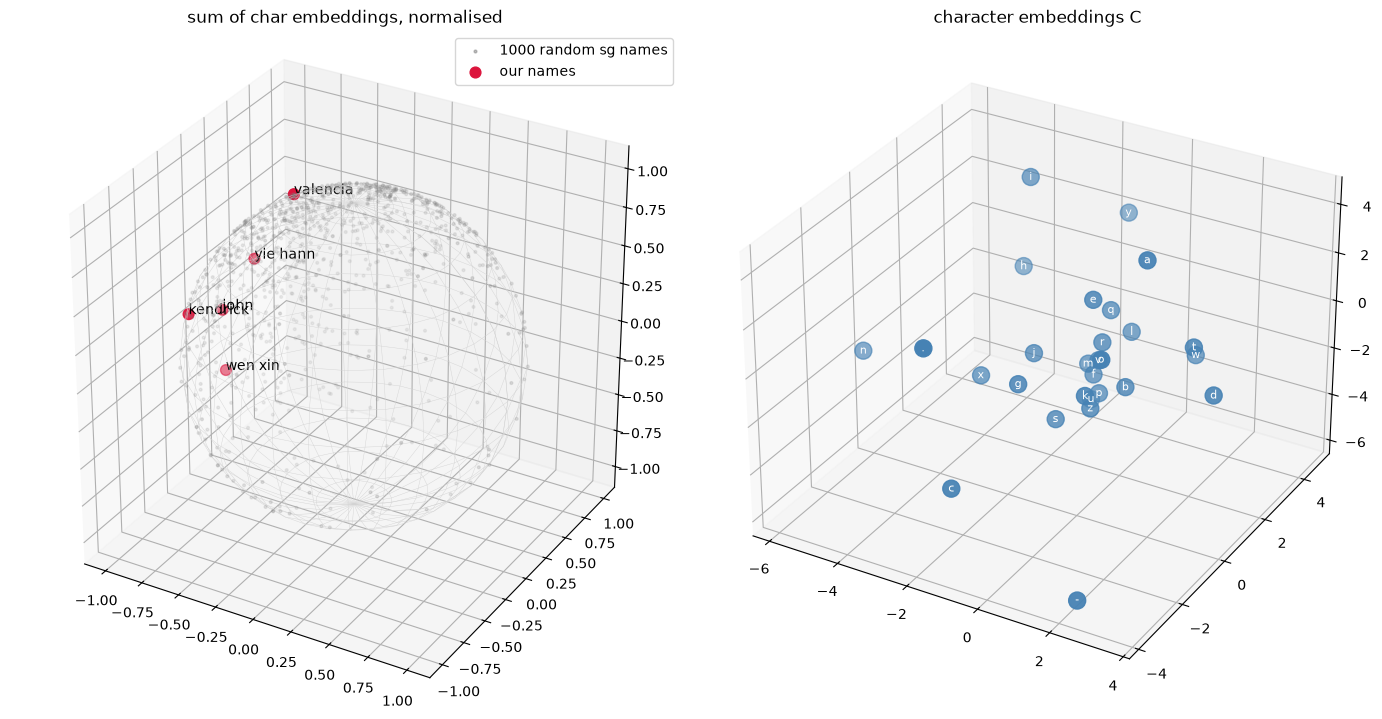

In [13]:
# this was generated by AI cuz i cant draw nicely
fig = plt.figure(figsize=(14, 7))

#left: names on the unit sphere
ax = fig.add_subplot(1, 2, 1, projection='3d')
u = torch.linspace(0, 2 * torch.pi, 30)
w = torch.linspace(0, torch.pi, 15)
ax.plot_wireframe(torch.outer(u.cos(), w.sin()), torch.outer(u.sin(), w.sin()),
                  torch.outer(torch.ones_like(u), w.cos()), color='lightgray', linewidth=0.3)
ax.scatter(*bg_vecs.T, s=4, color='gray', alpha=0.5, label='1000 random sg names')
ax.scatter(*my_vecs.T, s=60, color='crimson', label='our names')
for n, v in zip(my_names, my_vecs):
    ax.text(*v.tolist(), n, fontsize=10)
ax.set_box_aspect((1, 1, 1))  # so the sphere looks round
ax.set_title('sum of char embeddings, normalised')
ax.legend()

#right: the raw character embeddings the names are built from
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
Cd = C.detach()
ax2.scatter(*Cd.T, s=150, color='steelblue')
for i in range(Cd.size(0)):
    ax2.text(*Cd[i].tolist(), itos[i], ha='center', va='center', color='white', fontsize=8)
ax2.set_title('character embeddings C')

plt.tight_layout()
plt.show()

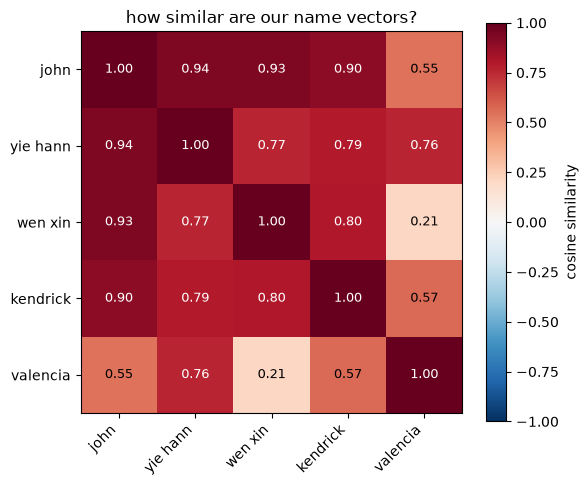

In [14]:
#cosine similarity heatmap: vectors are already length 1, so a dot product = cos(angle between them). designed by AI lol
sims = my_vecs @ my_vecs.T  # (n_names, n_names)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sims, cmap='RdBu_r', vmin=-1, vmax=1)  # red = similar, white = unrelated, blue = opposite

ax.set_xticks(range(len(my_names)), my_names, rotation=45, ha='right')
ax.set_yticks(range(len(my_names)), my_names)

#write the number in each square, white text on dark squares so it stays readable
for i in range(len(my_names)):
    for j in range(len(my_names)):
        s = sims[i, j].item()
        ax.text(j, i, f'{s:.2f}', ha='center', va='center',
                color='white' if abs(s) > 0.6 else 'black', fontsize=9)

fig.colorbar(im, ax=ax, label='cosine similarity')
ax.set_title('how similar are our name vectors?')
plt.tight_layout()
plt.show()

# Figure 2: diagram showing semantic similarity between name vectors. 
Its pretty interesting to see the numbers. Its just a random scale of how close 2 peoples names are (1 being super close and -1 being not close) based on the summation of their name's vector embeddings in 3d space :) 

introducing higher dimension embeddings might help to encode more information so that the similarity index actually accounts for more information but its not relevant lol. 

i wonder what fun patterns emerge when we look at the differences between the characters in the names 


In [15]:
#this nice visual was generated by ai to show path taken in mapping our names lol
#experiment 2b: interactive 3d view of the path each name takes on the unit sphere as its characters are added
#drag to rotate, scroll to zoom, hover for details, drag the slider (or press play) to type the names out
#click a name in the legend to hide it, double-click to show only that name
#uses: C, stoi, itos (training cells), clean_name + my_names (cell 28), torch (imports)
import html
import plotly.graph_objects as go
from IPython.display import HTML, display

steps_per_char = 12  # smoothness of each arc
palette = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#9a6324']

@torch.no_grad()
def name_path(name):
    """Normalised running sum of char embeddings, sampled along each step so the arcs are smooth."""
    ix = [stoi[ch] for ch in clean_name(name)]
    total = torch.zeros(C.size(1))
    arc, n_typed = [], []
    for k, i in enumerate(ix):
        t = torch.linspace(0, 1, steps_per_char).unsqueeze(1)  # (steps, 1)
        seg = total + t * C[i]                                  # slide from the old sum to the new sum
        if k == 0:
            seg = seg[1:]                                       # zero vector has no direction, skip it
        arc.append(seg / seg.norm(dim=1, keepdim=True))         # project every point onto the sphere
        n_typed += [k + 1] * len(seg)                           # how many chars are typed at each point
        total = total + C[i]
    return torch.cat(arc), torch.tensor(n_typed)

paths = {n: name_path(n) for n in my_names}
max_len = max(len(clean_name(n)) for n in my_names)

def name_traces(k):
    """Line + moving head for every name, with the first k characters typed."""
    traces = []
    for j, (n, (arc, n_typed)) in enumerate(paths.items()):
        col, name = palette[j % len(palette)], clean_name(n)
        seg = arc[n_typed <= k] if k > 0 else arc[:0]
        head = seg[-1:] if len(seg) else arc[:0]
        typed = name[:k]
        traces.append(go.Scatter3d(
            x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode='lines', line=dict(color=col, width=6),
            name=n, legendgroup=n, hoverinfo='skip'))
        traces.append(go.Scatter3d(
            x=head[:, 0], y=head[:, 1], z=head[:, 2], mode='markers+text',
            marker=dict(size=9 if k < len(name) else 12, color=col,
                        symbol='circle' if k < len(name) else 'diamond',
                        line=dict(color='white', width=1)),
            text=[typed], textposition='top center', textfont=dict(color=col, size=14),
            name=n, legendgroup=n, showlegend=False,
            hovertemplate=f'<b>{typed}</b><br>(%{{x:.2f}}, %{{y:.2f}}, %{{z:.2f}})<extra>{n}</extra>'))
    return traces

#static background: translucent unit sphere + where each single character points on it
u = torch.linspace(0, 2 * torch.pi, 60)
w = torch.linspace(0, torch.pi, 30)
sphere = go.Surface(
    x=torch.outer(u.cos(), w.sin()), y=torch.outer(u.sin(), w.sin()), z=torch.outer(torch.ones_like(u), w.cos()),
    opacity=0.12, colorscale=[[0, '#9aa5b1'], [1, '#9aa5b1']], showscale=False, hoverinfo='skip')
with torch.no_grad():
    letter_dirs = C[1:] / C[1:].norm(dim=1, keepdim=True)  # skip '.', it never appears in the sums
letters = go.Scatter3d(
    x=letter_dirs[:, 0], y=letter_dirs[:, 1], z=letter_dirs[:, 2], mode='text',
    text=[itos[i] for i in range(1, C.size(0))], textfont=dict(color='#7b8794', size=11),
    name='single letters', hovertemplate='letter <b>%{text}</b><extra></extra>')

n_static = 2  # sphere + letters; the name traces come after these
fig = go.Figure(
    data=[sphere, letters] + name_traces(max_len),
    frames=[go.Frame(data=name_traces(k), name=str(k), traces=list(range(n_static, n_static + 2 * len(paths))))
            for k in range(max_len + 1)])

axis = dict(range=[-1.15, 1.15], showbackground=False, gridcolor='#e4e7eb', zerolinecolor='#cbd2d9',
            showspikes=False)
fig.update_layout(
    title='names being typed on the unit sphere (sum of char embeddings, normalised)',
    height=720, margin=dict(l=0, r=0, t=50, b=0),
    scene=dict(xaxis=axis, yaxis=axis, zaxis=axis, aspectmode='cube',
               camera=dict(eye=dict(x=1.5, y=1.5, z=0.9))),
    legend=dict(x=0.01, y=0.95),
    updatemenus=[dict(
        type='buttons', x=0.01, y=0.02, xanchor='left', yanchor='bottom', direction='left',
        buttons=[dict(label='▶ play', method='animate',
                      args=[None, dict(frame=dict(duration=600, redraw=True), fromcurrent=False,
                                       transition=dict(duration=0))]),
                 dict(label='❚❚ pause', method='animate',
                      args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])])],
    sliders=[dict(
        active=max_len, x=0.2, len=0.78, y=0.02, currentvalue=dict(prefix='characters typed: '),
        steps=[dict(label=str(k), method='animate',
                    args=[[str(k)], dict(mode='immediate', frame=dict(duration=0, redraw=True))])
               for k in range(max_len + 1)])])
#render inside an iframe: this JupyterLab doesn't have the plotly display extension, so fig.show() comes out blank
page = fig.to_html(include_plotlyjs='cdn', auto_play=False)  # loads plotly.js from the internet
display(HTML(f'<div><iframe srcdoc="{html.escape(page)}" style="width:100%; height:760px; border:none;"></iframe></div>'))

# Fig 3: path mapped by names on a unit circle
So we break down each cahracter in the name and go character by character. If you drag the slider to the first character, you see the initial vector positions of the letters. (the grey peripheral letters are the vectors of other characters)

sliding the slider to the end after all 8 characters are typed, we see the path taken by the normalised vector of our names 

i think its a cool visualisation tool. lmk if u think its cool :D